# Anomaly Detection

DecisionTree, RandomForest, KNN classifiers 

In [1]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Create Synthetic Data


In [3]:
np.random.seed(42)
nSamples=600
perClass=nSamples//4
data=[]

for i in range(perClass):
    data.append({"batteryDrop":np.random.uniform(1,8),
                  "speed":np.random.uniform(8,15),
                  "routeDeviation":np.random.uniform(0,4),
                  "altChange":np.random.uniform(0,5),
                  "speedChange":np.random.uniform(0,4),
                  "label":"Normal"})
for i in range(perClass):
    data.append({"batteryDrop":np.random.uniform(12,40),
                  "speed":np.random.uniform(5,14),
                  "routeDeviation":np.random.uniform(0,5),
                  "altChange":np.random.uniform(0,6),
                  "speedChange":np.random.uniform(0,5),
                  "label":"BatteryAnomaly"})
for i in range(perClass):
    data.append({"batteryDrop":np.random.uniform(1,10),
                  "speed":np.random.uniform(5,13),
                  "routeDeviation":np.random.uniform(6,20),
                  "altChange":np.random.uniform(0,7),
                  "speedChange":np.random.uniform(0,5),
                  "label":"RouteAnomaly"})
for i in range(perClass):
    data.append({"batteryDrop":np.random.uniform(1,9),
                  "speed":np.random.uniform(7,16),
                  "routeDeviation":np.random.uniform(0,5),
                  "altChange":np.random.uniform(10,35),
                  "speedChange":np.random.uniform(8,25),
                  "label":"SensorSpike"})

df=pd.DataFrame(data).sample(frac=1,random_state=42).reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['label'].value_counts()}")
df.head(10)

Dataset shape: (600, 6)
Class distribution:
label
Normal            150
RouteAnomaly      150
SensorSpike       150
BatteryAnomaly    150
Name: count, dtype: int64


,batteryDrop,speed,routeDeviation,altChange,speedChange,label
0,4.641145,13.965271,2.207627,2.804690,3.506614,Normal
1,8.135690,9.620747,14.884154,5.585399,1.979852,RouteAnomaly
2,7.784337,13.559753,0.476996,20.717551,8.495886,SensorSpike
3,6.624367,9.974242,0.709758,3.753074,3.227339,Normal
4,36.994808,12.356992,1.709087,1.556541,1.898462,BatteryAnomaly
5,20.852371,9.565113,0.207864,0.890059,4.933151,BatteryAnomaly
6,7.787092,13.425930,3.757996,4.474137,2.391600,Normal
7,6.348581,13.108030,1.809600,24.841520,8.172230,SensorSpike
8,7.933536,10.888324,1.488072,3.882065,1.363214,Normal
9,5.332097,5.153538,9.637385,5.322029,0.685549,RouteAnomaly


## Exploratory Data Analysis

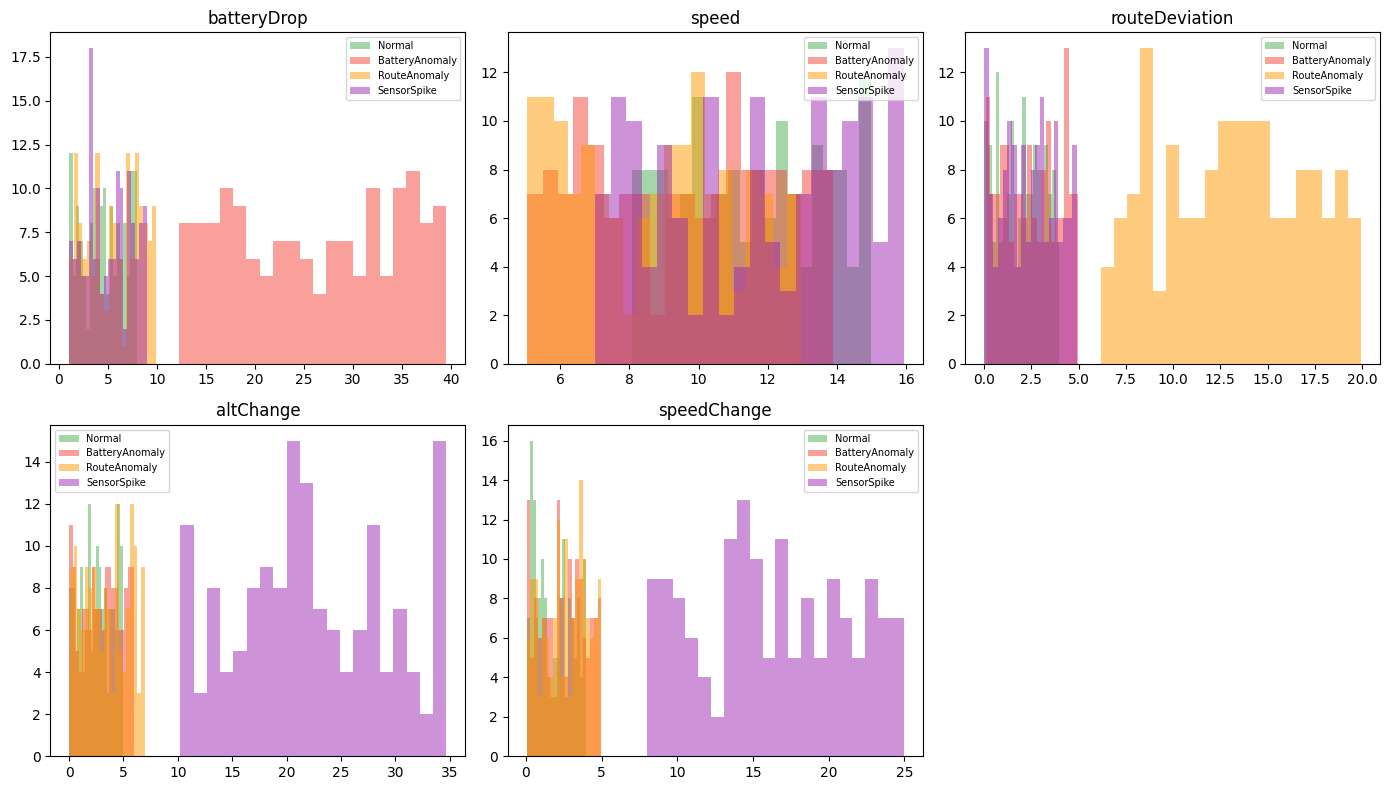

In [4]:
#feature distributions by class
fig,axes=plt.subplots(2,3,figsize=(14,8))
feats=["batteryDrop","speed","routeDeviation","altChange","speedChange"]
colors={"Normal":"#4CAF50","BatteryAnomaly":"#F44336",
        "RouteAnomaly":"#FF9800","SensorSpike":"#9C27B0"}
for i,feat in enumerate(feats):
    ax=axes[i//3][i%3]
    for lbl,clr in colors.items():
        subset=df[df["label"]==lbl]
        ax.hist(subset[feat],bins=20,alpha=0.5,label=lbl,color=clr)
    ax.set_title(feat);ax.legend(fontsize=7)
axes[1][2].axis("off")
plt.tight_layout()
plt.show()

In [5]:
#Train/Test Split
feats=["batteryDrop","speed","routeDeviation","altChange","speedChange"]
X=np.array(df[feats].values,dtype=float)
y=np.array(df["label"].values)

xTr,xTe,yTr,yTe=train_test_split(X,y,test_size=0.2,random_state=42)
print(f"Train: {xTr.shape[0]} samples")
print(f"Test:  {xTe.shape[0]} samples")

Train: 480 samples
Test:  120 samples


## Classifiers & Evaluation Metrics

In [6]:
# Decision Tree
dt=DecisionTreeClassifier(max_depth=8,random_state=42)
dt.fit(xTr,yTr)
yPredDt=dt.predict(xTe)
accDt=accuracy_score(yTe,yPredDt)
print(f"DecisionTree Accuracy: {accDt:.4f}")
print(classification_report(yTe,yPredDt))

DecisionTree Accuracy: 1.0000
                precision    recall  f1-score   support

BatteryAnomaly       1.00      1.00      1.00        32
        Normal       1.00      1.00      1.00        27
  RouteAnomaly       1.00      1.00      1.00        33
   SensorSpike       1.00      1.00      1.00        28

      accuracy                           1.00       120
     macro avg       1.00      1.00      1.00       120
  weighted avg       1.00      1.00      1.00       120



In [7]:
# Random Forest
rf=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)
rf.fit(xTr,yTr)
yPredRf=rf.predict(xTe)
accRf=accuracy_score(yTe,yPredRf)
print(f"RandomForest Accuracy: {accRf:.4f}")
print(classification_report(yTe,yPredRf))

RandomForest Accuracy: 1.0000
                precision    recall  f1-score   support

BatteryAnomaly       1.00      1.00      1.00        32
        Normal       1.00      1.00      1.00        27
  RouteAnomaly       1.00      1.00      1.00        33
   SensorSpike       1.00      1.00      1.00        28

      accuracy                           1.00       120
     macro avg       1.00      1.00      1.00       120
  weighted avg       1.00      1.00      1.00       120



In [8]:
# KNN
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(xTr,yTr)
yPredKnn=knn.predict(xTe)
accKnn=accuracy_score(yTe,yPredKnn)
print(f"KNN Accuracy: {accKnn:.4f}")
print(classification_report(yTe,yPredKnn))

KNN Accuracy: 0.9917
                precision    recall  f1-score   support

BatteryAnomaly       1.00      1.00      1.00        32
        Normal       0.96      1.00      0.98        27
  RouteAnomaly       1.00      0.97      0.98        33
   SensorSpike       1.00      1.00      1.00        28

      accuracy                           0.99       120
     macro avg       0.99      0.99      0.99       120
  weighted avg       0.99      0.99      0.99       120



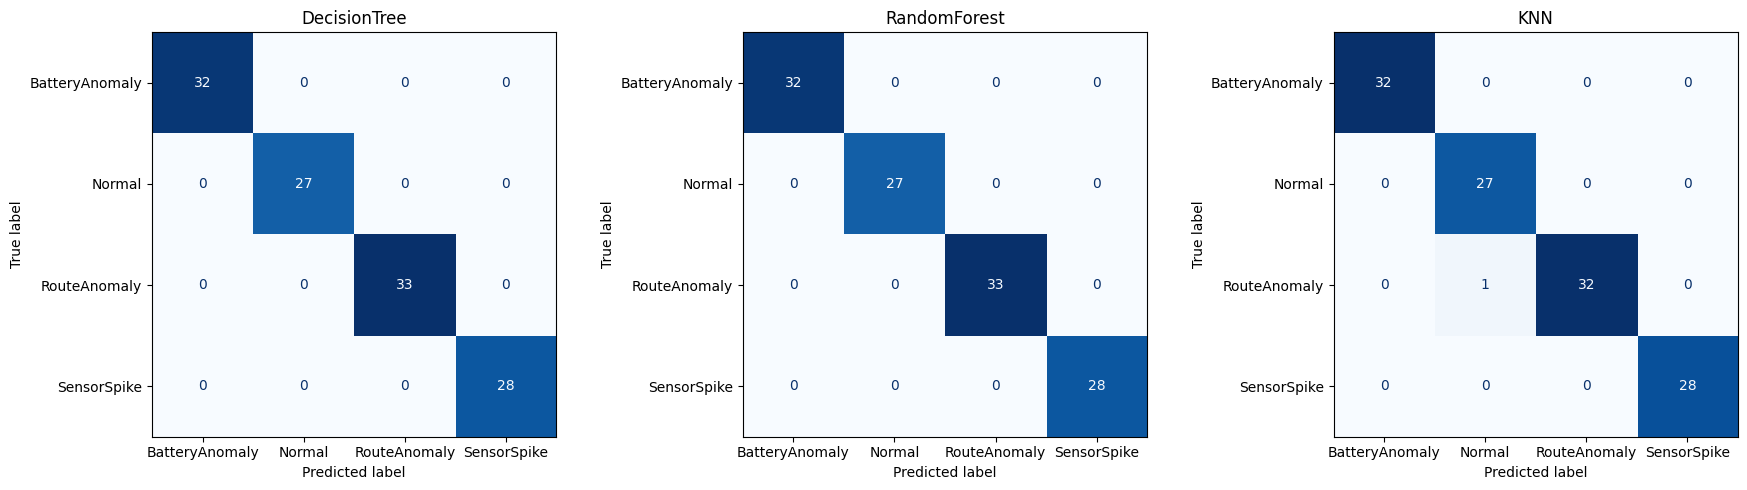

In [9]:
#Confusion Matrix
fig,axes=plt.subplots(1,3,figsize=(18,5))
labels=sorted(df["label"].unique())
for ax,yPred,name in zip(axes,
                          [yPredDt,yPredRf,yPredKnn],
                          ["DecisionTree","RandomForest","KNN"]):
    cm=confusion_matrix(yTe,yPred,labels=labels)
    disp=ConfusionMatrixDisplay(cm,display_labels=labels)
    disp.plot(ax=ax,cmap="Blues",colorbar=False)
    ax.set_title(f"{name}")
plt.tight_layout()
plt.show()

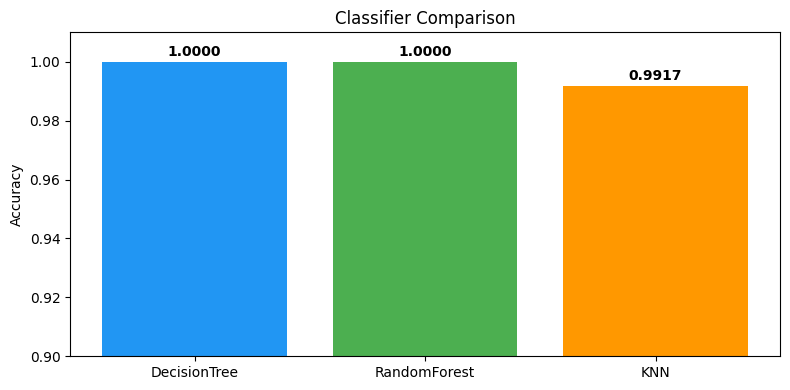

Best model: DecisionTree (Accuracy=1.0000)


In [10]:
#Accuracy
models=["DecisionTree","RandomForest","KNN"]
accs=[accDt,accRf,accKnn]

fig,ax=plt.subplots(figsize=(8,4))
bars=ax.bar(models,accs,color=["#2196F3","#4CAF50","#FF9800"])
ax.set_ylim(0.9,1.01)
ax.set_ylabel("Accuracy");ax.set_title("Classifier Comparison")
for bar,acc in zip(bars,accs):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.002,
            f"{acc:.4f}",ha="center",fontweight="bold")
plt.tight_layout()
plt.show()

bestMdl=models[np.argmax(accs)]
print(f"Best model: {bestMdl} (Accuracy={max(accs):.4f})")

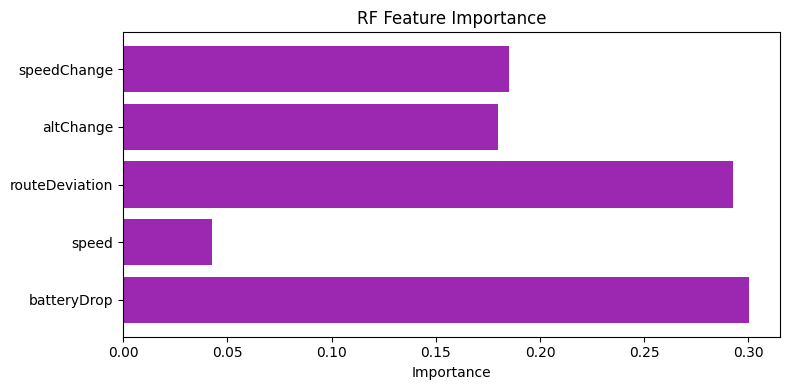

In [11]:
#RF feature importance
imprt=rf.feature_importances_
featNames=["batteryDrop","speed","routeDeviation","altChange","speedChange"]
fig,ax=plt.subplots(figsize=(8,4))
ax.barh(featNames,imprt,color="#9C27B0")
ax.set_xlabel("Importance");ax.set_title("RF Feature Importance")
plt.tight_layout()
plt.show()